In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# case
import numpy as np
from utils.iea22s import IEA22s
from utils.sites import Hornsrev1Site

# this is a smoother version of PyWake IEA22 that works better with wake steering optimization
wt = IEA22s()
wds = np.arange(0, 360, 0.5)
wss = np.arange(3, 25, 0.5)
(x, y), site = Hornsrev1Site(
    scale_D=wt.diameter()  # scale up the layout based on turbine diameter ratio
)
TI = 0.04  # site.local_wind().TI_ilk.ravel()s
n_threads = 32

In [3]:
# predict LUT
from utils.easy import easy_yaw_gnn

# work with ~PyWake-style inputs
yaws = easy_yaw_gnn(x, y, wd=wds, ws=wss, TI=TI, num_threads=n_threads, batch_size=8192)

INFO:utils.to_graph: generated 31680 graphs from 31680 cases


'generate_graphs // n=1 // 306.262 s // total=306 s'

'graph_maker_lut // n=1 // 306.303 s // total=306 s'

'predict_torchscript // n=1 // 76.886 s // total=77 s'

'torchscript_to_lut // n=1 // 0.043 s // total=0 s'

'easy_yaw_gnn // n=1 // 383.585 s // total=384 s'

In [4]:
# Report uplift
from utils.get_flowmodel import get_flowmodel

wf_model = get_flowmodel(wt=wt, site=site)

sim_base = wf_model(x=x, y=y, wd=wds, ws=wss, TI=TI, yaw=0, tilt=0, n_cpu=32)
sim_gnn = wf_model(x=x, y=y, wd=wds, ws=wss, TI=TI, yaw=yaws, tilt=0, n_cpu=32)

aep_base = sim_base.aep().sum().values
print(aep_base)
aep_gnn = sim_gnn.aep().sum().values
print(aep_gnn)
uplift = 100 * (aep_gnn - aep_base) / aep_base
print(f"AEP uplift: {uplift:.2f}%")

8266.880584741106
8346.598771085564
AEP uplift: 0.96%


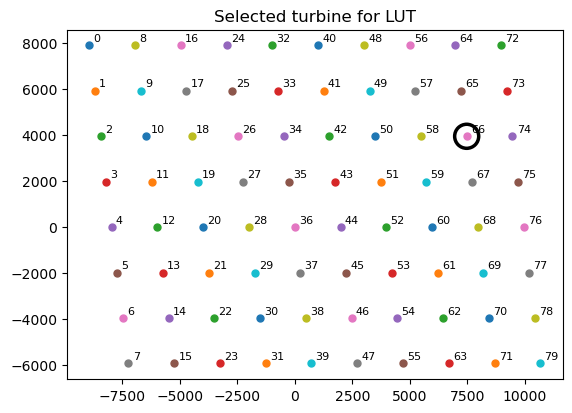

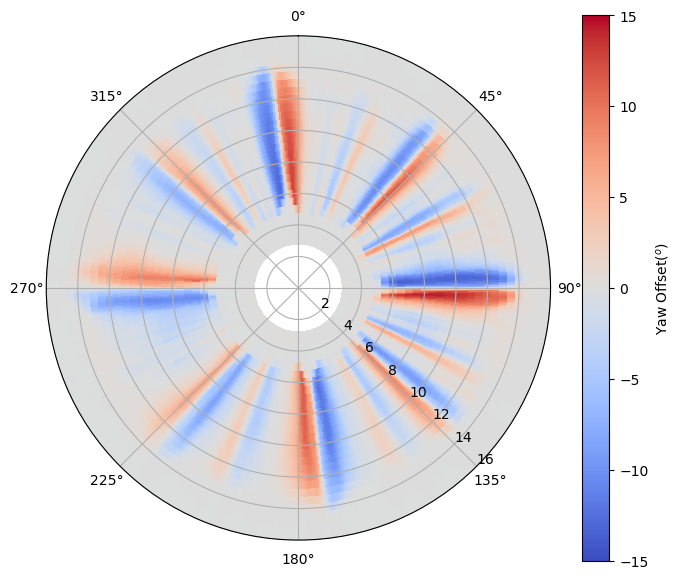

In [5]:
# plot look-up-table based on predictions
turbine_idx = int(66)  # select a turbine to plot

import matplotlib.pyplot as plt

plt.figure()
for i, (xi, yi) in enumerate(zip(x, y)):
    plt.scatter(xi, yi, s=25)
    plt.annotate(
        str(i),
        (xi, yi),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8,
    )
plt.gca().set_aspect("equal", adjustable="box")
plt.scatter(
    x[turbine_idx],
    y[turbine_idx],
    marker="o",
    facecolors="none",
    edgecolors="k",
    linewidths=2.5,
    s=300,
)
plt.title('Selected turbine for LUT')
plt.show()

# Plot LUT for turbine_idx
from utils.plot_utils import lut_3d_heatmap

lut_3d_heatmap(yaws[turbine_idx, :, :], wds=wds, wss=wss)

In [8]:
# predict timeseries
n_t = 8760  # set ts to genereate
wdt = np.random.uniform(0, 360, n_t)
wst = np.random.uniform(3, 25, n_t)
# TI = np.random.uniform(0.02, 0.14, n_t)
TI = np.array(0.04)
num_threads = 1

# predict timeseries yaw
from utils.easy import easy_yaw_gnn

yaws_t = easy_yaw_gnn(
    x, y, wd=wdt, ws=wst, TI=TI, num_threads=n_threads, batch_size=2048, time=True
)

# try yaw on timeseries and eval with PyWake
from utils.get_flowmodel import get_flowmodel

wf_model = get_flowmodel(wt=wt, site=site)

sim_base = wf_model(x=x, y=y, wd=wdt, ws=wst, TI=TI, yaw=0, tilt=0, n_cpu=4, time=True)
sim_gnn = wf_model(
    x=x, y=y, wd=wdt, ws=wst, TI=TI, yaw=yaws_t, tilt=0, n_cpu=4, time=True
)

aep_base = sim_base.aep().sum().values
print(aep_base)
aep_gnn = sim_gnn.aep().sum().values
print(aep_gnn)
uplift = 100 * (aep_gnn - aep_base) / aep_base
print(f"AEP uplift (random(uniform) time series): {uplift:.2f}%")

11556.64377266515
11597.775688156025
AEP uplift (random(uniform) time series): 0.36%


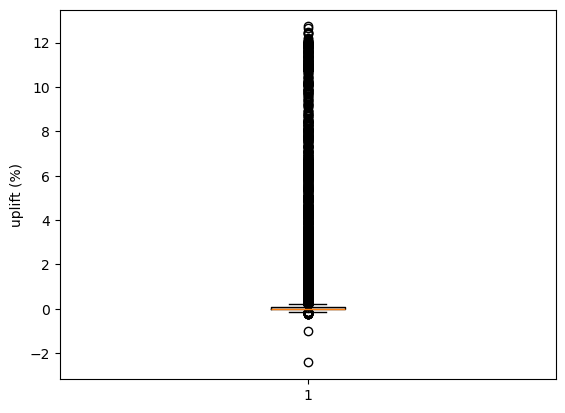

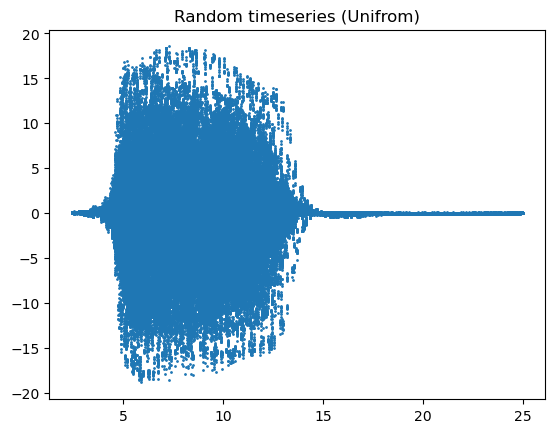

In [9]:
uplift = (sim_gnn.Power.sum("wt") - sim_base.Power.sum('wt')) / sim_base.Power.sum('wt')
plt.boxplot(100*uplift)
plt.ylabel('uplift (%)')
plt.show()
plt.scatter(sim_gnn.WS_eff.values, yaws_t, s=1)
plt.title('Random timeseries (Unifrom)')
plt.show()

# Basic cases

In [10]:
# case
import numpy as np

TI = np.atleast_1d(0.04)
n_threads = 1
D = 284
wd_ = 270
ws_ = 7
X = np.array([0, D * 2])
Y = np.array([0, 0])

wtup_Y_offset = np.arange(-2 * D, 2 * D, 1)
n_cases = len(wtup_Y_offset)
Xs = np.full((n_cases, 2), X)
Ys = np.full((n_cases, 2), Y)
upstream_idx = 0
Ys[:, upstream_idx] = Ys[:, upstream_idx] + wtup_Y_offset

wss = np.full(n_cases, ws_)
wds = np.full(n_cases, wd_)
TIs = np.full(n_cases, TI)

INFO:utils.to_graph: generated 1136 graphs from 1136 cases


'generate_graphs // n=6 // 0.673 s // total=604 s'

'graph_maker_sequential // n=4 // 0.689 s // total=4 s'

'predict_torchscript // n=6 // 0.279 s // total=298 s'

'easy_yaw_gnn // n=6 // 0.977 s // total=604 s'

INFO:utils.to_graph: generated 1136 graphs from 1136 cases
INFO:utils.to_graph: generated 1136 graphs from 1136 cases
INFO:utils.to_graph: generated 1136 graphs from 1136 cases


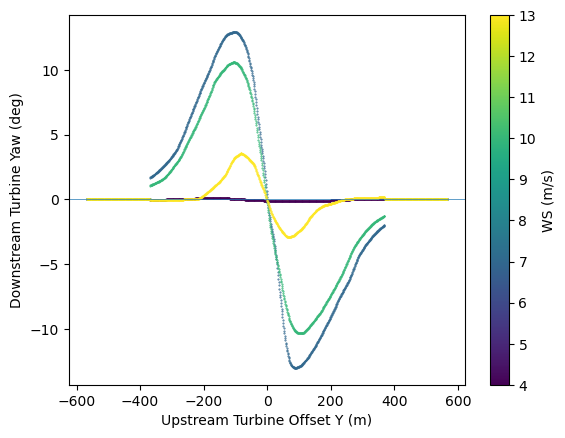

In [11]:
from matplotlib.colors import Normalize
from utils.easy import easy_yaw_gnn

ws_sweep = np.arange(4, 15, 3)  # m/s
fig, ax = plt.subplots()
cmap = plt.get_cmap("viridis")
norm = Normalize(vmin=min(ws_sweep), vmax=max(ws_sweep))

for ws_sw in ws_sweep:
    wss_ = np.full(n_cases, ws_sw)
    yaws = easy_yaw_gnn(
        Xs,
        Ys,
        wd=wds,
        ws=wss_,
        TI=TIs,
        num_threads=n_threads,
        batch_size=2048,
        sequential=True,
    )
    c = cmap(norm(ws_sw))
    ax.scatter(wtup_Y_offset, yaws[:, 0], s=0.2, color=c)  # upstream
    # ax.scatter(wtup_Y_offset, yaws[:, 1], s=1, color=c, alpha=0.5)  # downstream

ax.set_xlabel("Upstream Turbine Offset Y (m)")
ax.set_ylabel("Downstream Turbine Yaw (deg)")
ax.axhline(0, lw=0.5)
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="WS (m/s)")
plt.show()

In [12]:
from utils.plot_utils import plot_turbine_graph
from utils.to_graph import graph_maker_sequential

graphs = graph_maker_sequential(
    Xs,
    Ys,
    wds=wds,
    wss=wss_,
    TIs=TIs,
    num_threads=n_threads,
    connectivity="wake_aware",
)

INFO:utils.to_graph: generated 1136 graphs from 1136 cases


'generate_graphs // n=7 // 0.672 s // total=605 s'

'graph_maker_sequential // n=5 // 0.688 s // total=5 s'

(<Figure size 700x700 with 1 Axes>,
 <Axes: title={'center': "layout_id=0000500 | connectivity=wake_aware | yaws_method=robust_slsqp | info=['0000500', '2', 'PLayGen'] | wd_deg=270.0 | ws=13.0 | ti=0.03999999910593033 | farm_center_x=284.0 | farm_center_y=-34.0"}, xlabel='x', ylabel='y'>)

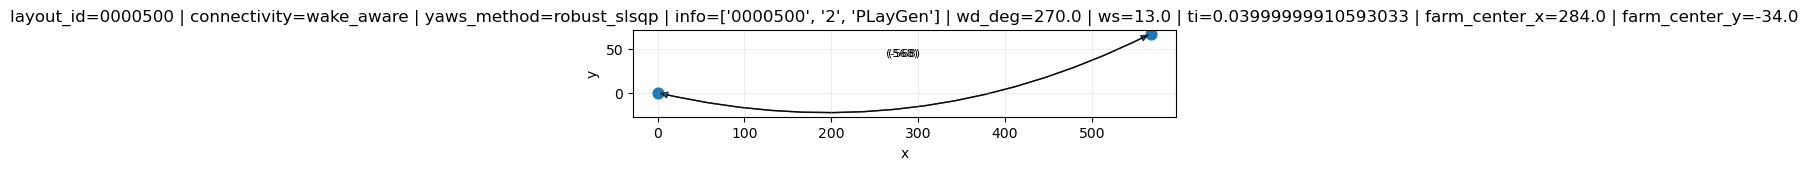

In [13]:
plot_turbine_graph(graphs[500])

# GNN scaling  

# GNN bee sensitivity